# Tarea 4 - Minería de datos - Actividad 1

Gabriel Elías Chanchí Golondrino

Maestría en Ciencia de Datos

Universidad Nacional Abierta y a Distancia

Presentado a: Profesor BRAYAN ANDRU MONTENEGRO EMBUS

# Introducción

El aprendizaje supervisado es un enfoque del machine learning en el cual se parte de datos etiquetados para ajustar modelos y luego predecir la posible instancia de instancias con las cuales los modelos no han sido entrenados. En este sentido la capacidad de generalizaciòn puede ser evaluada mediante el uso de las mètricas derivadas de la matriz de confusión como son: precision, recall, F1-score.

En este trabajo se realizó el ajuste y la evaluación de los modelos de árboles de decisión y Random Forest con 100 estimadores sobre un dataset del área comercial que cuenta con atributos tales como user_id, age, annual_income, purchase_amount, loyalty_score, region y purchase_frequency. A partir de los atributos del dataset se considero pertinente y útil tomar la variable region como variable categórica predictora, realizando la conversión de las categorías tipo cadena a categorías numéricas.

Los resultados obtenidos en este trabajo constituyen una base metodológica para extrapolar el enfoque al contexto comercial real. En particular, la capacidad de predecir la ubicación del cliente a partir de atributos asociados a su comportamiento de compra (como ingresos, frecuencia y monto de consumo) permite a las organizaciones identificar patrones geográficos sin depender exclusivamente de datos explícitos de localización. Esto ofrece ventajas estratégicas como la segmentación de mercados, la personalización de campañas, la optimización de la logística y la identificación de zonas con alto potencial comercial.

## Actividad 1 - Desarrollo de modelo de árboles de decisión

Desarrollar un proyecto completo de análisis predictivo sobre cinco instancias creadas por el estudiante, utilizando herramientas de computación en la nube. Trabajará con Databricks o Google Colab para implementar un modelo sobre un conjunto de datos (Anexo 1 - Dataset3.csv), aplicando las fases clave del aprendizaje automático: desde la exploración y preparación de datos incluyendo la limpieza y transformación necesaria hasta la evaluación del modelo (20%). Deberá implementar el algoritmo de Árboles de decisión y aplicar validación
cruzada para optimizar el rendimiento, finalmente crear visualizaciones
necesarias para comprender los resultados incluyendo la curva ROC.

## Análisis exploratorio de los datos

Empezamos por cargar el dataset de trabajo y presentar sus primeros 5 registros.

In [ ]:
import pandas as pd
df = pd.read_csv('Anexo 1 - Dataset3.csv', delimiter=";")
df.head()

,user_id,age,annual_income,purchase_amount,loyalty_score,region,purchase_frequency
0,1,25,45000,200,4.5,North,12
1,2,34,55000,350,7.0,South,18
2,3,45,65000,500,8.0,West,22
3,4,22,30000,150,3.0,East,10
4,5,29,47000,220,4.8,North,13


Procedemos con la descripción de las diferentes columnas del dataset cargado <br>

**user_id:** Identificador único de cada usuario dentro del conjunto de datos.<br>
**age:** Edad del usuario, expresada en años.<br>
**annual_income:** Ingreso anual del usuario en dólares.<br>
**purchase_amount:** Monto de dinero que el usuario ha gastado en una compra específica o en promedio.<br>
**loyalty_score:** Puntaje que representa el nivel de lealtad del cliente hacia la marca o negocio.<br>
**region:** Región geográfica donde se encuentra el usuario (por ejemplo, North, South, East, West).<br>
**purchase_frequency:** Frecuencia con la que el usuario realiza compras en un período determinado<br>

Obtenemos el tamaño del dataset mediante el atributo shape y observamos que está conformado por un total de 238 instancias.

In [ ]:
df.shape

(238, 7)
































Procedemos con la identificación de los tipos de datos de las diferentes columnas del dataset. Se aprecia que las columnas numéricas tienen un tipo de dato numérico y también que la única columna ("region") que tiene cadenas de caracteres es de tipo object.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   user_id             238 non-null    int64  
 1   age                 238 non-null    int64  
 2   annual_income       238 non-null    int64  
 3   purchase_amount     238 non-null    int64  
 4   loyalty_score       238 non-null    float64
 5   region              238 non-null    object 
 6   purchase_frequency  238 non-null    int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 13.1+ KB


Aunque en la revisión anterior apreciamos que el dataset no cuenta con valores nulos, procedemos con la revisión de los valores nulos del dataset. En este caso se aprecia que el dataset no cuenta con valores nulos.

In [ ]:
df.isna().sum()

,0
user_id,0
age,0
annual_income,0
purchase_amount,0
loyalty_score,0
region,0
purchase_frequency,0


Considerando que la columna user_id es secuencial y el objetivo es identificar patrones no se considera dentro del análisis y procedemos a borrarla del dataframe.

In [ ]:
df_sel = df.drop('user_id', axis=1)
df_sel.head()

,age,annual_income,purchase_amount,loyalty_score,region,purchase_frequency
0,25,45000,200,4.5,North,12
1,34,55000,350,7.0,South,18
2,45,65000,500,8.0,West,22
3,22,30000,150,3.0,East,10
4,29,47000,220,4.8,North,13


Ahora procedemos a revisar la distribución de los datos en el dataset mediante el uso del método describe(). El dataset cuenta con 238 registros y refleja un comportamiento bastante equilibrado en sus variables. La edad de los usuarios va desde los 22 hasta los 55 años, con un promedio cercano a los 39 años y una variabilidad moderada, lo que sugiere un grupo relativamente diverso pero sin extremos muy marcados. En cuanto al ingreso anual, los valores se sitúan entre 30,000 y 75,000, con una media de alrededor de 57,400, mostrando diferencias económicas notables entre los usuarios. El monto de compra presenta una mayor dispersión, ya que oscila entre 150 y 640, con un promedio de 425.6, lo que indica distintos niveles de gasto. Por su parte, el loyalty score se mantiene en un rango de 3.0 a 9.5, con una media de 6.79 y poca variación, lo que sugiere que la mayoría de los clientes tienen un nivel de lealtad relativamente similar. Finalmente, la frecuencia de compra varía entre 10 y 28, con un promedio cercano a 20, lo que indica que los usuarios tienden a comprar con cierta regularidad. En general, la cercanía entre la media y la mediana en las variables sugiere distribuciones bastante balanceadas.

In [ ]:
df_sel.describe()

,age,annual_income,purchase_amount,loyalty_score,purchase_frequency
count,238.000000,238.000000,238.000000,238.000000,238.000000
mean,38.676471,57407.563025,425.630252,6.794118,19.798319
std,9.351118,11403.875717,140.052062,1.899047,4.562884
min,22.000000,30000.000000,150.000000,3.000000,10.000000
25%,31.000000,50000.000000,320.000000,5.500000,17.000000
50%,39.000000,59000.000000,440.000000,7.000000,20.000000
75%,46.750000,66750.000000,527.500000,8.275000,23.000000
max,55.000000,75000.000000,640.000000,9.500000,28.000000


Creamos ahora los diagramas de boxplot por atributos.Los boxplots muestran que, en general, las variables presentan distribuciones bastante equilibradas. La edad se concentra entre aproximadamente 31 (Q1) y 47 años (Q3), con una mediana cercana a 39, lo que indica que la mayoría de los usuarios son adultos de mediana edad. El ingreso anual tiene su rango intercuartílico entre 50,000 y 66,750, con una mediana alrededor de 59,000, reflejando ingresos relativamente estables sin grandes sesgos. En cuanto al monto de compra, el 50% central de los datos se sitúa entre 320 y 527.5, con una mediana de 440, lo que sugiere una variabilidad moderada en el gasto. El loyalty score presenta un rango intercuartílico más estrecho (entre 5.5 y 8.27), con mediana en 7, indicando que la mayoría de los clientes tienen niveles de lealtad similares. Finalmente, la frecuencia de compra se distribuye entre 17 (Q1) y 23 (Q3), con una mediana cercana a 20, lo que evidencia un comportamiento de compra bastante consistente. Así mismo es importante apreciar que no se observan outliers marcados y las distribuciones lucen bastante balanceadas.

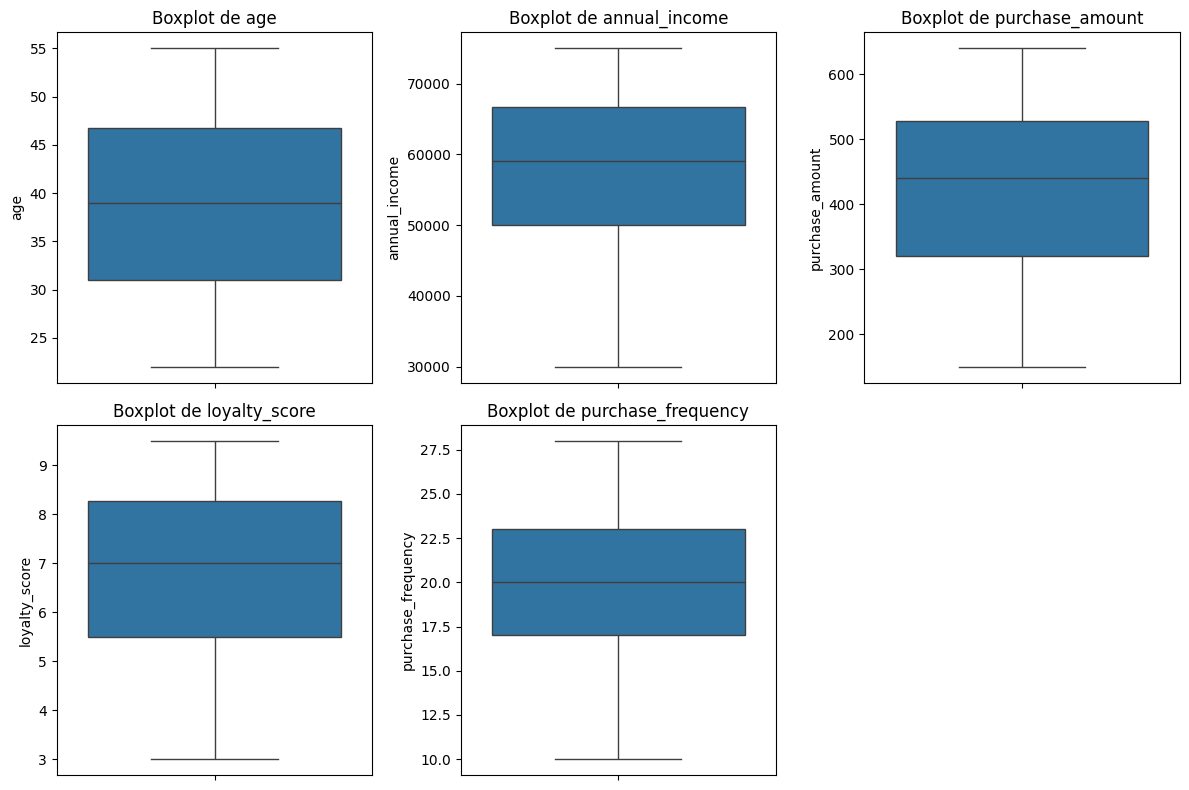

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Variables numéricas
columnas = ['age', 'annual_income', 'purchase_amount', 'loyalty_score', 'purchase_frequency']
#Crear figura con subplots (2 filas, 3 columnas)
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()  # Para recorrerlos fácilmente
for i, col in enumerate(columnas):
    sns.boxplot(y=df_sel[col], ax=axes[i])
    axes[i].set_title(f'Boxplot de {col}')

#Eliminar subplot vacío (5 variables y 6 espacios)
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

Ahora realizamos la gráfica de boxplot en la cual comparamos el monto de compra con respecto al atributo categórico región. Al observar la relación entre el monto de compra y la región, se nota que la región West destaca claramente por tener los valores más altos, con una mediana superior al resto, lo que sugiere que allí los clientes tienden a gastar más. En contraste, East y North presentan medianas más bajas y comportamientos bastante similares, indicando niveles de gasto más moderados. Por su parte, South se ubica en un punto intermedio, aunque con cierta variabilidad y la presencia de un posible valor atípico bajo. Lo anterior sugiere que la región influye en el comportamiento de compra, siendo West la más fuerte en términos de gasto, mientras que las demás regiones muestran patrones más contenidos.

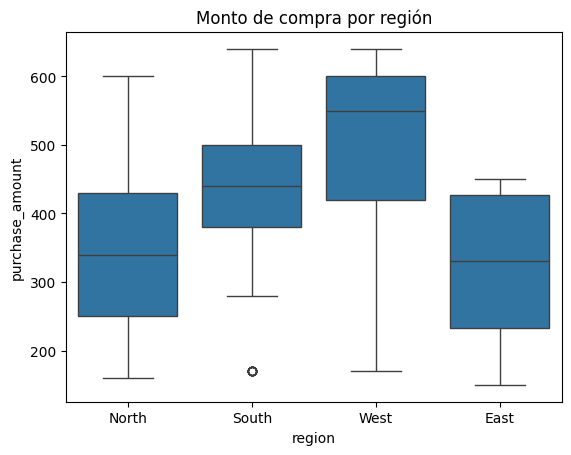

In [ ]:
plt.figure()
sns.boxplot(x='region', y='purchase_amount', data=df_sel)
plt.title('Monto de compra por región')
plt.show()

Ahora realizamos los diagramas de boxplot que relacionan las variables purchase_frecuency y region, con el fin de identificar las variaciones en frecuencia de compra por región. A partir del diagrama de boxplot que relaciona la frecuencia de compra con las regiones es posible observar que existen diferencias claras en el comportamiento de los compradores según su ubicación. La región Oeste presenta, en general, las frecuencias de compra más altas, con una mediana superior al resto, lo que sugiere un mayor nivel de actividad o fidelidad de los clientes en esta zona. Por otro lado, la región Sur también muestra valores relativamente elevados, aunque con algo más de dispersión y presencia de valores atípicos bajos. De otra parte, las regiones Norte y Este evidencian medianas más bajas, indicando una menor frecuencia de compra, aunque con rangos intercuartílicos amplios que reflejan cierta variabilidad entre los clientes. Estos hallazgos sugieren que la región influye significativamente en la frecuencia de compra, siendo el Oeste el mercado más activo y consistente, mientras que el Norte y el Este presentan comportamientos más moderados y heterogéneos.

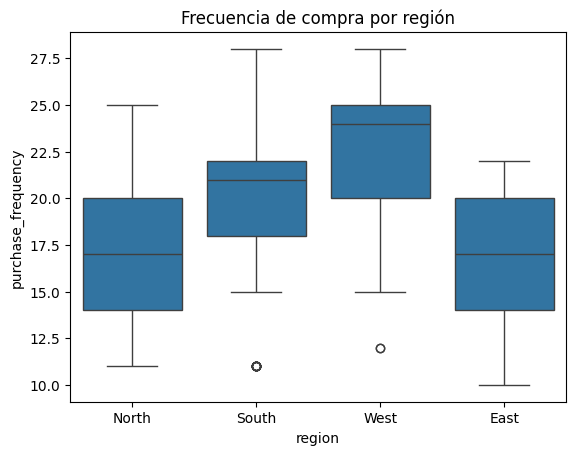

In [ ]:
plt.figure()
sns.boxplot(x='region', y='purchase_frequency', data=df_sel)
plt.title('Frecuencia de compra por región')
plt.show()

Ahora generamos un diagrama de boxplot para relacionar la edad con la region. A partir del diagrama de boxplot que relaciona la edad con las regiones es posible observar que existen diferencias claras en el perfil etario de los compradores, de tal modo que la región Oeste destaca por concentrar a los clientes de mayor edad, seguida por el Sur con una distribución también relativamente madura, mientras que el Norte y el Este agrupan a consumidores más jóvenes en promedio. Al concectar este resultado con el análisis previo de la frecuencia de compra, se aprecia un patrón coherente: las regiones con mayor edad promedio, especialmente el Oeste, son también las que presentan una mayor frecuencia de compra, lo que sugiere que los clientes más adultos tienden a comprar con mayor regularidad. De otra parte, las regiones con poblaciones más jóvenes, como el Norte y el Este, muestran frecuencias de compra más bajas, lo que podría reflejar hábitos de consumo menos consolidados. Estos hallazgos apuntan a una relación entre la edad y el comportamiento de compra que varía según la región.

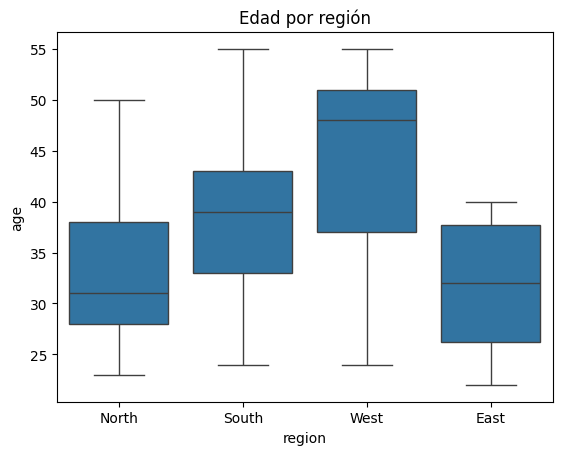

In [ ]:
plt.figure()
sns.boxplot(x='region', y='age', data=df_sel)
plt.title('Edad por región')
plt.show()

Finalmente relacionamos el atributo de puntaje de lealtad (loyalty_score) con la región donde se realizaron las compras. A partir del diagrama de boxplot que relaciona el loyalty score con las regiones es posible observar que la región Oeste vuelve a destacar, presentando los niveles de lealtad más altos y consistentes entre sus clientes, seguida por el Sur con valores también elevados aunque algo más dispersos; en contraste, el Norte y el Este muestran puntuaciones de lealtad más bajas y variables. Al relacionar estos resultados con los análisis previos, se refuerza la idea de que las regiones con clientes de mayor edad, como el Oeste y en menor medida el Sur, no solo compran con mayor frecuencia, sino que también exhiben un mayor nivel de fidelización. Por el contrario, las regiones con poblaciones más jóvenes, como el Norte y el Este, presentan tanto menor frecuencia de compra como niveles de lealtad más moderados, lo que sugiere que la madurez del cliente podría estar asociada a relaciones más estables y recurrentes con la marca.

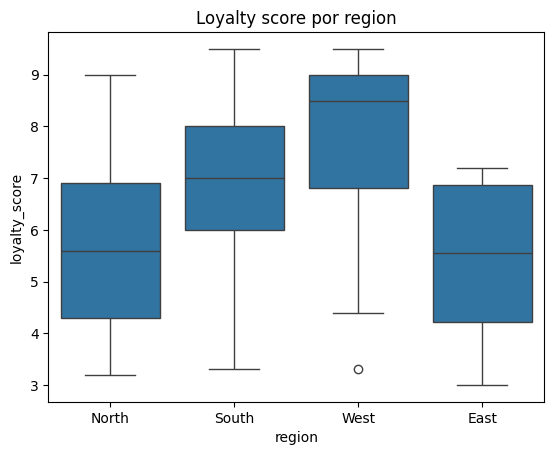

In [ ]:
plt.figure()
sns.boxplot(x='region', y='loyalty_score', data=df_sel)
plt.title('Loyalty score por region')
plt.show()

Ahora bien, teniendo en cuenta que las regiones permiten la diferenciación de varios de los atributos a nivel de los diagramas de boxplot, se procede con la selección del atributo *region* como variable predictora. No obstante, previo a su uso en modelos de aprendizaje automático, se hace necesario transformar las categorías tipo cadena en representaciones numéricas, con el fin de que puedan ser procesadas adecuadamente en el entorno de Python. Cabe mencionar que la inclusión de la variable *region* como predictor puede ser de gran utilidad, ya que permite capturar patrones geográficos y contextuales asociados al comportamiento de los clientes, tales como diferencias en niveles de ingreso, frecuencia de compra o montos de consumo. En este sentido, la región actúa como un proxy de factores socioeconómicos y culturales que no están explícitamente modelados en el conjunto de datos, contribuyendo potencialmente a mejorar la capacidad predictiva del modelo y a enriquecer la interpretación de los resultados obtenidos.

De acuerdo con lo anterior cambiamos de cadena a valor numérico las categorías de la columna region. De este modo el mapeo realizado en la columna region_num fue:

- East: 1
- North: 2
- South: 3
- West: 4

In [ ]:
df['region_num'] = df['region'].astype('category').cat.codes+1
df.head()

,user_id,age,annual_income,purchase_amount,loyalty_score,region,purchase_frequency,region_num
0,1,25,45000,200,4.5,North,12,2
1,2,34,55000,350,7.0,South,18,3
2,3,45,65000,500,8.0,West,22,4
3,4,22,30000,150,3.0,East,10,1
4,5,29,47000,220,4.8,North,13,2


Seleccionamos ahora las columnas a usar en el dataset, descartando la columna "region" e incluimos la columna "region_num"

In [ ]:
df_tree=df[['age','annual_income','purchase_amount','purchase_frequency','loyalty_score','region_num']]
df_tree.head()

,age,annual_income,purchase_amount,purchase_frequency,loyalty_score,region_num
0,25,45000,200,12,4.5,2
1,34,55000,350,18,7.0,3
2,45,65000,500,22,8.0,4
3,22,30000,150,10,3.0,1
4,29,47000,220,13,4.8,2


Ahora procedemos a hacer un gráfico de pairplot entre las variables involucradas, relacionándolas con la variable region_num derivada de la variable region. La gráfica de pairplot muestra una fuerte correlación positiva entre loyalty_score y las variables purchase_amount y purchase_frequency, evidenciando que el comportamiento de compra es el principal factor asociado a la lealtad. annual_income también presenta una relación positiva, aunque menos pronunciada, mientras que age muestra una correlación más moderada y con mayor dispersión. Del mismo modo, en contraste, region_num no evidencia una separación clara, por lo que su capacidad predictiva es menor frente a las variables transaccionales.

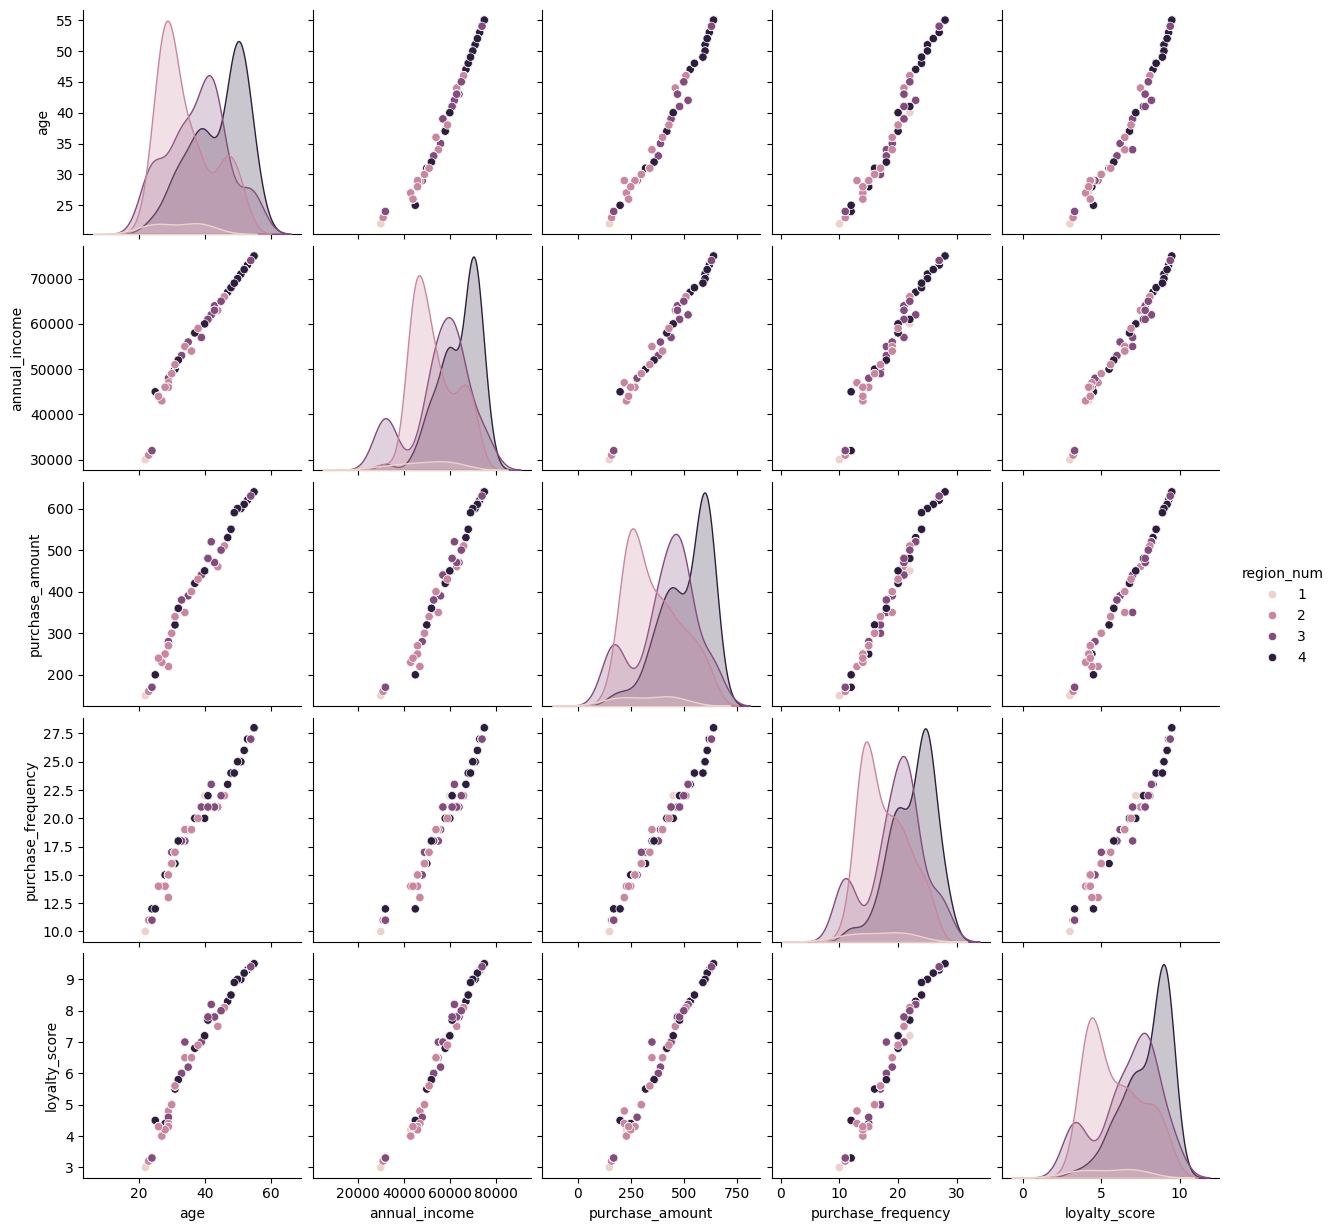

In [ ]:
import seaborn as sns

sns.pairplot(
    df_tree,
    vars=['age', 'annual_income', 'purchase_amount', 'purchase_frequency', 'loyalty_score'],
    hue='region_num'
)

## Partición del dataset en entrenamiento y prueba

Ahora,  separamos el dataset en entrenamiento y prueba con 20% para el conjunto de prueba. Usamos el parámetro stratify teniendo en cuenta que se tienen 4 categorías en el atributo a predecir region y se pretende el entrenamiento equilibrado del modelo en las diferentes categorías.Del mismo modo, el particionado del dataset se hace con semilla aleatoria para hacer replicables los datos.

In [ ]:
from sklearn.model_selection import train_test_split
#Seleccionamos las variables X y y
X = df_tree.drop('region_num', axis=1)
y = df_tree['region_num']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X.head()

,age,annual_income,purchase_amount,purchase_frequency,loyalty_score
0,25,45000,200,12,4.5
1,34,55000,350,18,7.0
2,45,65000,500,22,8.0
3,22,30000,150,10,3.0
4,29,47000,220,13,4.8


## Aplicación de la validación cruzada

Aplicamos la validación cruzada con 3 folds sobre el 80% de los datos destinados al entrenamiento, obteniendo en este caso un accuracy de 86.88%, lo que indica una adecuada capacidad de ajuste del modelo sin evidencias de sobreajuste. Este resultado se complementa con métricas como una precision de 65.76%, un recall de 66.92% y un F1-score cercano al 66.14%, las cuales reflejan un desempeño moderado en la discriminación entre clases. En particular, aunque el modelo logra clasificar correctamente una proporción considerable de los casos, las métricas de precisión y recall sugieren que aún existen dificultades para identificar de manera equilibrada todas las clases, posiblemente debido a solapamientos en los datos o a la limitada capacidad predictiva del atributo region_num. En conjunto, estos indicadores evidencian un modelo funcional, con resultados consistentes, pero con margen de mejora en su capacidad de generalización y discriminación.



In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.tree import DecisionTreeClassifier
from sklearn.exceptions import UndefinedMetricWarning
import warnings
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

model = DecisionTreeClassifier(random_state=42)
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision_macro',
    'recall': 'recall_macro',
    'f1': 'f1_macro'
}

scores = cross_validate(model, X_train, y_train, cv=3, scoring=scoring)

print("Accuracy:", scores['test_accuracy'].mean())
print("Precision:", scores['test_precision'].mean())
print("Recall:", scores['test_recall'].mean())
print("F1:", scores['test_f1'].mean())

Accuracy: 0.8687996031746031
Precision: 0.6576236280171871
Recall: 0.6692460317460318
F1: 0.6613545756777922


## Evaluación del modelo con el conjunto de prueba

Evaluamos ahora el modelo con el conjunto de prueba (20% de los datos), obteniendo un accuracy de 79.16%, valor que resulta coherente y cercano al desempeño observado durante la validación cruzada con el conjunto de entrenamiento. Esta disminución es esperable, ya que el modelo se enfrenta a datos no vistos previamente. En conjunto, estos resultados evidencian una adecuada capacidad de generalización, indicando que el modelo no presenta sobreajuste y mantiene un desempeño consistente al ser aplicado sobre nuevos datos, aunque con un margen de mejora en la discriminación de las distintas clases.

In [ ]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score
print("Accuracy en test:", accuracy_score(y_test, y_pred))

Accuracy en test: 0.7916666666666666


Obtenemos las demás métricas sobre el conjunto de prueba, donde se evidencia un desempeño consistente con respecto a los resultados obtenidos durante la validación cruzada en el conjunto de entrenamiento. En particular, el modelo alcanza valores de precision, recall y F1-score elevados para las clases mayoritarias (2, 3 y 4), con resultados que oscilan entre 0.73 y 0.88, lo que indica una adecuada capacidad de clasificación en estos grupos. Sin embargo, para la clase 1 no se logra una predicción correcta (valores de 0.00), lo cual se explica por su baja representatividad en los datos. A nivel global, se obtiene un accuracy cercano al 79%, junto con un F1-score ponderado de aproximadamente 0.78, valores que guardan coherencia con los obtenidos en entrenamiento (alrededor del 86% de accuracy y 66% de F1 macro). En conjunto, estos resultados confirman que el modelo generaliza de manera razonable, aunque presenta limitaciones en la identificación de clases minoritarias.


In [ ]:
from sklearn.metrics import classification_report
from sklearn.exceptions import UndefinedMetricWarning
import warnings
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.00      0.00      0.00         1
           2       0.72      0.81      0.76        16
           3       0.88      0.88      0.88        16
           4       0.79      0.73      0.76        15

    accuracy                           0.79        48
   macro avg       0.60      0.61      0.60        48
weighted avg       0.78      0.79      0.78        48



## Obtención de la matriz de confusión

Ahora obtenemos la matriz de confusión del modelo. La matriz de confusión del conjunto de prueba muestra un desempeño adecuado, aunque no perfecto. Se observa una concentración de valores en la diagonal principal (13, 14 y 11 para las clases 2, 3 y 4), indicando una correcta clasificación en la mayoría de los casos. Sin embargo, la clase 1 no es identificada correctamente debido a su baja representatividad, y se presentan algunas confusiones entre las clases 2, 3 y 4. En conjunto, el modelo distingue razonablemente bien las clases principales, pero presenta limitaciones en la clasificación de la clase minoritaria y en la separación de categorías cercanas.

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 0  1  0  0]
 [ 0 13  0  3]
 [ 0  2 14  0]
 [ 0  2  2 11]]


Ahora visualizamos de manera más clara la matriz de confusión usando la librería seaborn.

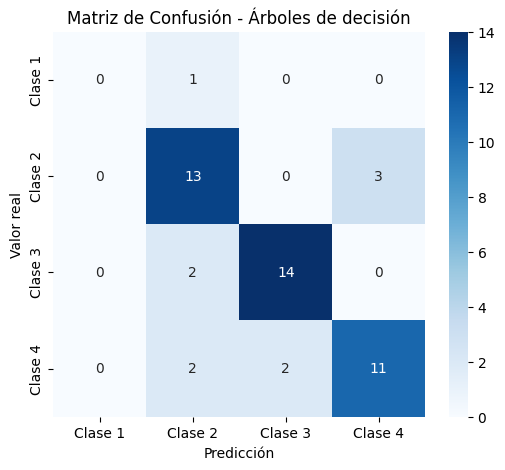

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

#Calcular la matriz
cm = confusion_matrix(y_test, y_pred)

#Etiquetas de las clases (ajústalas a tu caso)
labels = ["Clase 1", "Clase 2", "Clase 3", "Clase 4"]

#Creamos el heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,       #Mostrar valores
            fmt="d",          #Formato entero
            cmap="Blues",     #Paleta de colores
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de Confusión - Árboles de decisión")
plt.show()

## Generación de la curva ROC

Se grafica la curva ROC multiclase, evidenciando un desempeño heterogéneo del modelo. Las clases 2 y 3 presentan una buena capacidad de discriminación, con valores de AUC cercanos a 0.90, seguidas de la clase 4 con un AUC de 0.87. En contraste, la clase 1 muestra un desempeño bajo (AUC ≈ 0.47), lo que indica una capacidad limitada para distinguir esta categoría. De este modo, el modelo discrimina adecuadamente las clases principales, aunque presenta debilidades en la identificación de la clase minoritaria.

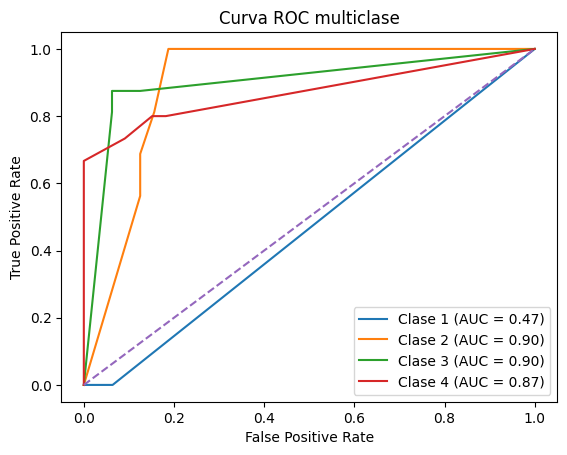

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

#Binarizar las clases
y_test_bin = label_binarize(y_test, classes=[1, 2, 3, 4])

n_classes = y_test_bin.shape[1]

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
  fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
  roc_auc[i] = auc(fpr[i], tpr[i])

#Graficar
plt.figure()
for i in range(0, n_classes):
  plt.plot(fpr[i], tpr[i], label=f'Clase {i+1} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC multiclase')
plt.legend()
plt.show()

# Actividad 2 - Desarrollo de modelo de Random Forest

## Evaluación de Random Forest mediante Validación Cruzada

Ahora se aplica el modelo de Random Forest utilizando 100 estimadores y validación cruzada con 5 folds sobre el conjunto de entrenamiento, obteniendo un accuracy de 87.90%, una precision de 66.35%, recall de 67.76% y un F1-score de 66.79%. En comparación con el modelo de árboles de decisión, se observa una ligera mejora, particularmente en el accuracy (≈1.02%) y en el recall (≈0.84%), mientras que el F1-score se mantiene prácticamente estable. Estos resultados sugieren un comportamiento marginalmente más robusto del Random Forest, aunque sin diferencias sustanciales en el desempeño global.

In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision_macro',
    'recall': 'recall_macro',
    'f1': 'f1_macro'
}

scores = cross_validate(model, X_train, y_train, cv=5, scoring=scoring)

print("Accuracy:", scores['test_accuracy'].mean())
print("Precision:", scores['test_precision'].mean())
print("Recall:", scores['test_recall'].mean())
print("F1:", scores['test_f1'].mean())

Accuracy: 0.8789473684210526
Precision: 0.663464035964036
Recall: 0.6775641025641026
F1: 0.6678770585292324


## Evaluación de Random Forest con el conjunto de prueba

Ahora se evalúa el modelo de Random Forest sobre el conjunto de prueba, obteniendo un accuracy de 77.08%. Este resultado es inferior al observado durante la validación cruzada en el conjunto de entrenamiento (≈87.90%), lo cual es esperable al enfrentarse a datos no vistos previamente. En comparación con el modelo de árboles de decisión, se mantiene un comportamiento similar, evidenciando una ligera disminución en el desempeño, lo que indica que aunque el modelo generaliza razonablemente bien, aún presenta cierto margen de mejora en su capacidad predictiva sobre nuevos datos.

In [ ]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score
print("Accuracy en test:", accuracy_score(y_test, y_pred))

Accuracy en test: 0.7708333333333334


Ahora se obtienen las diferentes métricas sobre el conjunto de prueba, donde se evidencia un desempeño consistente con respecto a los resultados de la validación cruzada. En particular, las clases mayoritarias (2, 3 y 4) presentan valores adecuados de precision, recall y F1-score (entre 0.73 y 0.81), mientras que la clase 1 no es correctamente identificada debido a su baja representatividad. A nivel global, se obtiene un accuracy de 77% y un F1-score ponderado cercano a 0.76, valores ligeramente inferiores a los obtenidos en validación cruzada con el conjunto de entrenamiento (≈87.9% de accuracy y ≈0.67 de F1 macro). Ahora bien, en comparación con el modelo de árboles de decisión, el Random Forest muestra un comportamiento similar, manteniendo una diferencia moderada entre entrenamiento y prueba, lo que sugiere una generalización razonable aunque con limitaciones en clases minoritarias.


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.00      0.00      0.00         1
           2       0.72      0.81      0.76        16
           3       0.81      0.81      0.81        16
           4       0.79      0.73      0.76        15

    accuracy                           0.77        48
   macro avg       0.58      0.59      0.58        48
weighted avg       0.76      0.77      0.76        48



## Obtención de la matriz de confusión

Ahora se analiza la matriz de confusión del modelo Random Forest sobre el conjunto de prueba, de tal modo que se observa un desempeño adecuado pero no perfecto. Se presenta una concentración importante de valores en la diagonal principal (13, 13 y 11 para las clases 2, 3 y 4), lo que indica una correcta clasificación en la mayoría de los casos. Sin embargo, se evidencian errores fuera de la diagonal, particularmente en la clase 3, que muestra algunas confusiones hacia la clase 2, y en la clase 2, con casos clasificados como clase 4. Asi mismo, la clase 1 no es identificada correctamente debido a su baja representatividad. En comparación con el modelo de árboles de decisión, los resultados son muy similares, manteniendo patrones de confusión entre clases cercanas, lo que confirma un comportamiento consistente entre ambos modelos, aunque sin mejoras significativas en la capacidad de discriminación.

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 0  1  0  0]
 [ 0 13  0  3]
 [ 0  3 13  0]
 [ 0  1  3 11]]


Ahora generamos la matriz de confusión de una manera más estética usando la librería seaborn.

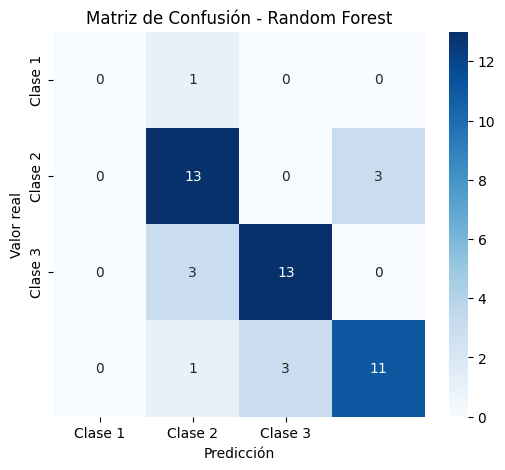

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

#Calculamos la matriz
cm = confusion_matrix(y_test, y_pred)

#Etiquetas de las clases (ajústalas a tu caso)
labels = ["Clase 1", "Clase 2", "Clase 3"]

#Crear el heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de Confusión - Random Forest")
plt.show()

## Obtención de la curva ROC

Ahora se presenta la curva ROC multiclase para el modelo de Random Forest, la cual evidencia un desempeño diferenciado entre clases. De modo particular, las clases 2 y 3 muestran una alta capacidad de discriminación, con valores de AUC de 0.92 y 0.93 respectivamente, seguidas de la clase 4 con un AUC de 0.88. Por otro lado, la clase 1 presenta un bajo desempeño (AUC ≈ 0.41), indicando dificultades para su correcta identificación. En comparación con el modelo de árboles de decisión, se observa un comportamiento similar, aunque con una ligera mejora en la capacidad de discriminación para las clases principales. De este modo, estos resultados son coherentes con las métricas y la matriz de confusión, evidenciando un buen desempeño general, pero con limitaciones en la clase minoritaria.

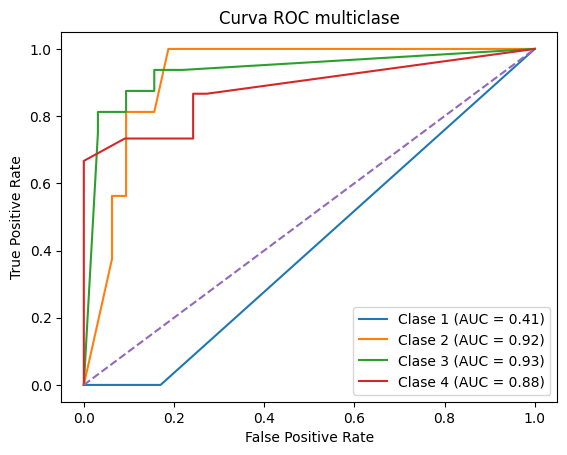

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

#Binarizar las clases
y_test_bin = label_binarize(y_test, classes=[1, 2, 3, 4])

n_classes = y_test_bin.shape[1]

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
  fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
  roc_auc[i] = auc(fpr[i], tpr[i])

#Graficar
plt.figure()
for i in range(n_classes):
  plt.plot(fpr[i], tpr[i], label=f'Clase {i+1} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC multiclase')
plt.legend()
plt.show()

## Conclusiones

- El análisis descriptivo de las variables del dataset permitió determinar entre otros patrones que las regiones con clientes de mayor edad, como el Oeste y en menor medida el Sur, no solo compran con mayor frecuencia, sino que también exhiben un mayor nivel de fidelización. En ese mismo sentido, las regiones con poblaciones más jóvenes, como el Norte y el Este, presentan tanto menor frecuencia de compra como niveles de lealtad más moderados, sugiriendo que la madurez del cliente podría estar asociada a relaciones más estables y recurrentes con la marca.

- Al emplear validación cruzada para evaluar los modelos de árboles de decisión y Random Forest, se observa un desempeño adecuado en ambos casos, con métricas de accuracy cercanas al 87% en entrenamiento. El modelo de Random Forest presenta una ligera mejora en estabilidad y recall, aunque las diferencias entre ambos modelos no son significativas.<br>

- La evaluación sobre el conjunto de prueba evidencia una disminución moderada en el desempeño (≈77–82% de accuracy), lo cual es consistente con la validación cruzada y sugiere una capacidad de generalización razonable. No obstante, ambos modelos presentan dificultades en la identificación de la clase minoritaria, lo cual impacta métricas como precision, recall y F1-score. <br>

- El análisis de la matriz de confusión y la curva ROC confirma que los modelos logran discriminar adecuadamente las clases mayoritarias, pero presentan limitaciones en clases con baja representatividad, especialmente la clase 1, lo cual afecta su desempeño global. <br>

- En cuanto a la selección de variables, se eligió la variable region como variable objetivo debido a su relación observable con otros atributos en los diagramas de boxplot. Para su uso en los modelos, sus categorías fueron transformadas a valores numéricos mediante un proceso de mapeo, dando lugar a la variable region_num, lo que permitió su adecuado procesamiento sin introducir complejidad adicional.<br>